<a href="https://colab.research.google.com/github/twyeh/university-physics/blob/%E9%9B%BB%E7%A3%81%E5%AD%B8/%E9%9D%9C%E9%9B%BB%E5%A0%B4%E8%A8%88%E7%AE%97_3D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 前言
利用符號計算程式協助計算複雜靜電場問題可以減少學習電場計算時遇到的數學困擾。
## 點電荷庫倫定律
根據庫倫定律，假設有一點電荷$Q$位在$S=(x,y,z)$,在空間一點$P=(x_p,y_p,z_p)$,則在$P$點的電場為 $\vec{E}$

\begin{equation}
\vec{E}(x_p,y_p,z_p)=k\frac{Q((x_p-x)\hat{i}+(y_p-y)\hat{j}+(z_p-z)\hat{k})}{((x_p-x)^2+(y_p-y)^2+(z_p-z)^2)^{3/2}}
\end{equation}

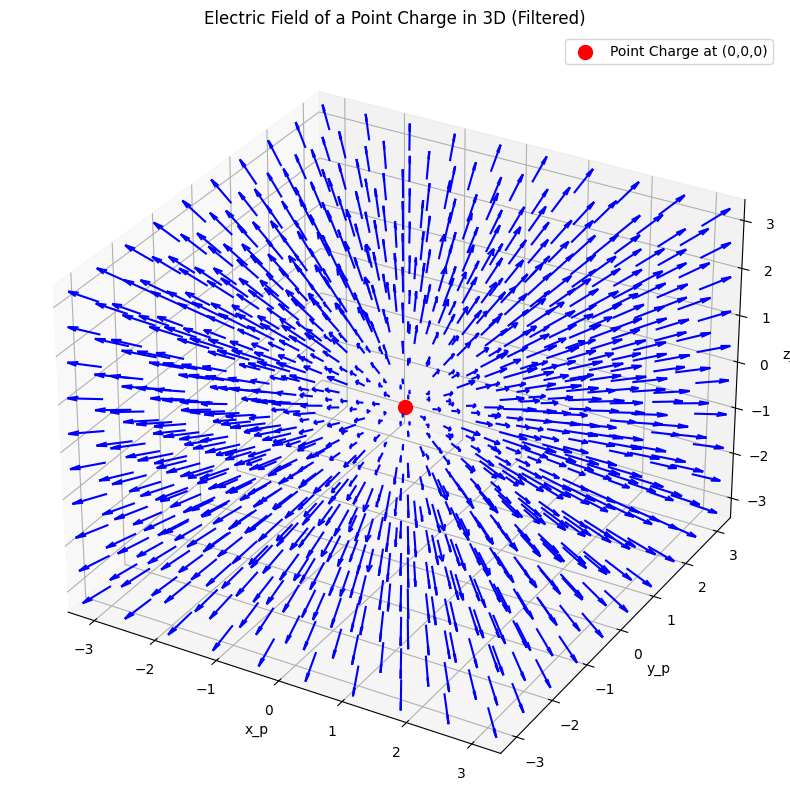

In [38]:
import sympy as sp
from sympy.vector import CoordSys3D
# Define a 3D Cartesian coordinate system
C = CoordSys3D('C')
# Define coordinate variabes
x,xp,y,yp,z,zp,k,Q = sp.symbols('x xp y yp z zp k Q')
# Define relevant vectors
s_vec = x*C.i + y*C.j + z*C.k # source point charge vector
p_vec = xp*C.i + yp*C.j + zp*C.k # observation point vector
r_vec = p_vec - s_vec # relative vector

r_mag = sp.sqrt(r_vec.dot(r_vec))
# Deine electrical field vector
E_vec = k*Q*r_vec/(r_mag**3)

Ex = sp.lambdify((x,xp,y,yp,z,zp,k,Q),E_vec.dot(C.i))
Ey = sp.lambdify((x,xp,y,yp,z,zp,k,Q),E_vec.dot(C.j))
Ez = sp.lambdify((x,xp,y,yp,z,zp,k,Q),E_vec.dot(C.k))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define constants for the point charge (from original setting for E_vec)
x_source = 0
y_source = 0
z_source = 0
k_val_point = 1 # k constant
Q_val_point = 1 # Q charge magnitude

# Create a 3D grid for visualization
x_vals = np.linspace(-3, 3, 10)
y_vals = np.linspace(-3, 3, 10)
z_vals = np.linspace(-3, 3, 10)
X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals)

# Calculate Ex, Ey, Ez components on the grid
# The order of arguments for lambdify is [x,y,z,xp,yp,zp,k,Q]
Ex_grid = Ex(x_source, X, y_source, Y, z_source, Z, k_val_point, Q_val_point)
Ey_grid = Ey(x_source, X, y_source, Y, z_source, Z, k_val_point, Q_val_point)
Ez_grid = Ez(x_source, X, y_source, Y, z_source, Z, k_val_point, Q_val_point)

# Calculate electric field magnitude for filtering
E_mag = np.sqrt(Ex_grid**2 + Ey_grid**2 + Ez_grid**2)

# Define a threshold for field strength to avoid plotting excessively large vectors near the charge
field_strength_threshold =0.5 # Adjusted for 3D visualization

# Create a mask for points below the threshold and not at the source point
mask = (E_mag < field_strength_threshold) & (X != x_source) & (Y != y_source) & (Z != z_source)

# Apply the mask to all relevant arrays
X_filtered = X[mask]
Y_filtered = Y[mask]
Z_filtered = Z[mask]
Ex_grid_filtered = Ex_grid[mask]
Ey_grid_filtered = Ey_grid[mask]
Ez_grid_filtered = Ez_grid[mask]

# Create the 3D quiver plot with filtered data
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

ax.quiver(X_filtered, Y_filtered, Z_filtered, Ex_grid_filtered, Ey_grid_filtered, Ez_grid_filtered, length=0.5, normalize=True, color='blue')

# Add the charge for context
ax.scatter(x_source, y_source, z_source, color='red', marker='o', s=100, label='Point Charge at (0,0,0)')

ax.set_xlabel('x_p')
ax.set_ylabel('y_p')
ax.set_zlabel('z_p')
ax.set_title('Electric Field of a Point Charge in 3D (Filtered)')
ax.legend()
ax.set_aspect('auto')

plt.show()

## 正負電偶極矩
若有兩個點電荷 $+Q=(a,0,0)$ 及 $-Q=(-a,0,0)$, 則在點$(x_P,y_P,z_P)$的電場向量為
\begin{equation}
\vec{E}(x_p,y_p,z_p)=k\frac{Q((x_p-a)\hat{i}+(y_p)\hat{j}+(z_p)\hat{k})}{((x_p-a)^2+(y_p)^2+(z_p)^2)^{3/2}} \\
- k\frac{Q((x_p+a)\hat{i}+(y_p)\hat{j}+(z_p)\hat{k})}{((x_p+a)^2+(y_p)^2+(z_p)^2)^{3/2}}
\end{equation}

In [ ]:
a = sp.symbols('a')
s1_vec = a*C.i + 0*C.j + 0*C.k # source point charge vector for +Q
s2_vec = -a*C.i + 0*C.j + 0*C.k # source point charge vector for -Q
p_vec = xp*C.i + yp*C.j + zp*C.k # observation point vector
r1_vec = p_vec - s1_vec # relative vector for +Q
r2_vec = p_vec - s2_vec # relative vector for -Q

r1_mag = sp.sqrt(r1_vec.dot(r1_vec))
r2_mag = sp.sqrt(r2_vec.dot(r2_vec))
# Define electrical field vector for a dipole (+Q at s1_vec, -Q at s2_vec)
Ed_vec = k*Q*r1_vec/(r1_mag**3) - k*Q*r2_vec/(r2_mag**3)
# show the expression
Ed_vec

In [ ]:
Ex_dipole = sp.lambdify((a,xp,yp,zp,k,Q),Ed_vec.dot(C.i))
Ey_dipole = sp.lambdify((a,xp,yp,zp,k,Q),Ed_vec.dot(C.j))
Ez_dipole = sp.lambdify((a,xp,yp,zp,k,Q),Ed_vec.dot(C.k))

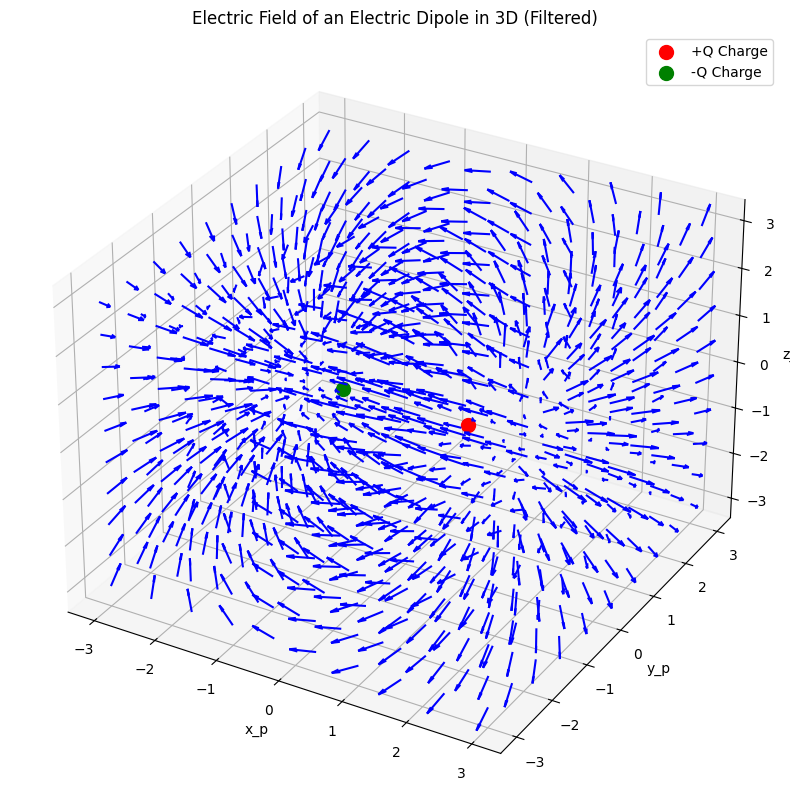

In [46]:
import sympy as sp
from sympy.vector import CoordSys3D
# Define a 3D Cartesian coordinate system
C = CoordSys3D('C')
# Define coordinate variables that are needed for dipole
xp,yp,zp,k,Q,a = sp.symbols('xp yp zp k Q a')

# Define vectors for dipole
s1_vec = a*C.i + 0*C.j + 0*C.k # source point charge vector for +Q
s2_vec = -a*C.i + 0*C.j + 0*C.k # source point charge vector for -Q
p_vec = xp*C.i + yp*C.j + zp*C.k # observation point vector
r1_vec = p_vec - s1_vec # relative vector for +Q
r2_vec = p_vec - s2_vec # relative vector for -Q

r1_mag = sp.sqrt(r1_vec.dot(r1_vec))
r2_mag = sp.sqrt(r2_vec.dot(r2_vec))
# Define electrical field vector for a dipole (+Q at s1_vec, -Q at s2_vec)
Ed_vec = k*Q*r1_vec/(r1_mag**3) - k*Q*r2_vec/(r2_mag**3)

# Lambdify the components of the electric field for the dipole
Ex_dipole = sp.lambdify((a,xp,yp,zp,k,Q),Ed_vec.dot(C.i))
Ey_dipole = sp.lambdify((a,xp,yp,zp,k,Q),Ed_vec.dot(C.j))
Ez_dipole = sp.lambdify((a,xp,yp,zp,k,Q),Ed_vec.dot(C.k))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define constants for the dipole
a_val_dipole = 1 # Distance from origin to each charge
k_val_dipole = 1 # k constant
Q_val_dipole = 1 # Q charge magnitude

# Create a 3D grid for visualization
x_vals_dipole = np.linspace(-3, 3, 10)
y_vals_dipole = np.linspace(-3, 3, 10)
z_vals_dipole = np.linspace(-3, 3, 10)
X_dipole, Y_dipole, Z_dipole = np.meshgrid(x_vals_dipole, y_vals_dipole, z_vals_dipole)

# Calculate Ex, Ey, Ez components on the grid
# The order of arguments for lambdify is [a,xp,yp,zp,k,Q]
Ex_grid_dipole = Ex_dipole(a_val_dipole, X_dipole, Y_dipole, Z_dipole, k_val_dipole, Q_val_dipole)
Ey_grid_dipole = Ey_dipole(a_val_dipole, X_dipole, Y_dipole, Z_dipole, k_val_dipole, Q_val_dipole)
Ez_grid_dipole = Ez_dipole(a_val_dipole, X_dipole, Y_dipole, Z_dipole, k_val_dipole, Q_val_dipole)

# Calculate electric field magnitude for filtering
E_mag_dipole = np.sqrt(Ex_grid_dipole**2 + Ey_grid_dipole**2 + Ez_grid_dipole**2)

# Define a threshold for field strength to avoid plotting excessively large vectors near the charges
field_strength_threshold_dipole = 0.5 # Adjusted for 3D visualization

# Create a mask for points below the threshold and not at the charge points
mask_dipole = (E_mag_dipole < field_strength_threshold_dipole) & \
              ~(((X_dipole == a_val_dipole) & (Y_dipole == 0) & (Z_dipole == 0)) | \
                ((X_dipole == -a_val_dipole) & (Y_dipole == 0) & (Z_dipole == 0)))

# Apply the mask to all relevant arrays
X_filtered_dipole = X_dipole[mask_dipole]
Y_filtered_dipole = Y_dipole[mask_dipole]
Z_filtered_dipole = Z_dipole[mask_dipole]
Ex_grid_filtered_dipole = Ex_grid_dipole[mask_dipole]
Ey_grid_filtered_dipole = Ey_grid_dipole[mask_dipole]
Ez_grid_filtered_dipole = Ez_grid_dipole[mask_dipole]

# Create the 3D quiver plot with filtered data
fig_dipole = plt.figure(figsize=(12, 10))
ax_dipole = fig_dipole.add_subplot(111, projection='3d')

ax_dipole.quiver(X_filtered_dipole, Y_filtered_dipole, Z_filtered_dipole,
                 Ex_grid_filtered_dipole, Ey_grid_filtered_dipole, Ez_grid_filtered_dipole,
                 length=0.4, normalize=True, color='blue')

# Add the charges for context
ax_dipole.scatter(a_val_dipole, 0, 0, color='red', marker='o', s=100, label='+Q Charge')
ax_dipole.scatter(-a_val_dipole, 0, 0, color='green', marker='o', s=100, label='-Q Charge')

ax_dipole.set_xlabel('x_p')
ax_dipole.set_ylabel('y_p')
ax_dipole.set_zlabel('z_p')
ax_dipole.set_title('Electric Field of an Electric Dipole in 3D (Filtered)')
ax_dipole.legend()
ax_dipole.set_aspect('auto')

plt.show()